<center><h1>Identification of Frost in Martian HiRISE Images</h1></center>

In [ ]:
# Import Packages

import os
import os.path as op
import json
from pathlib import Path
import shutil
import logging
import numpy as np
from tqdm import tqdm
from skimage import io
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Resizing
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.applications import ResNet50

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



### 1. (a),(b) Loading and pre processing the data

In [2]:
# Logging configuration
logging.basicConfig(level=logging.INFO,
                    datefmt='%H:%M:%S',
                    format='%(asctime)s | %(levelname)-5s | %(module)-15s | %(message)s')

IMAGE_SIZE = (299, 299)  # All images contained in this dataset are 299x299 (originally, to match Inception v3 input size)
SEED = 17

# Head directory containing all image subframes. Update with the relative path of your data directory
data_head_dir = Path('/content/drive/MyDrive/data_project/data')

# Find all subframe directories
subdirs = [Path(subdir.stem) for subdir in data_head_dir.iterdir() if subdir.is_dir()]
src_image_ids = ['_'.join(a_path.name.split('_')[:3]) for a_path in subdirs]

In [3]:
# Load train/val/test subframe IDs
def load_text_ids(file_path):
    """Simple helper to load all lines from a text file"""
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f.readlines()]
    return lines

# Load the subframe names for the three data subsets
train_ids = load_text_ids('/content/drive/MyDrive/train_source_images.txt')
validate_ids = load_text_ids('/content/drive/MyDrive/val_source_images.txt')
test_ids = load_text_ids('/content/drive/MyDrive/test_source_images.txt')

# Generate a list containing the dataset split for the matching subdirectory names
subdir_splits = []
for src_id in src_image_ids:
    if src_id in train_ids:
        subdir_splits.append('train')
    elif src_id in validate_ids:
        subdir_splits.append('validate')
    elif(src_id in test_ids):
        subdir_splits.append('test')
    else:
        logging.warning(f'{src_id}: Did not find designated split in train/validate/test list.')
        subdir_splits.append(None)

In [33]:
import random
import tensorflow as tf
from PIL import Image

def load_and_preprocess(img_loc, label):

    def _inner_function(img_loc, label):

        # Convert tensor to native type
        img_loc_str = img_loc.numpy().decode('utf-8')
        label_str = label.numpy().decode('utf-8')

        img = Image.open(img_loc_str).convert('RGB')
        img = img.resize((299, 299))  # Resize the image if it's not already 299x299
        img = np.array(img)  # Convert to numpy array
        img = img / 255.0  # Normalize the image to [0, 1] range

        # Convert to a TensorFlow tensor
        img = tf.convert_to_tensor(img, dtype=tf.float32)

        # Convert label to int and to a tensor
        label = tf.convert_to_tensor(1 if label_str == 'frost' else 0, dtype=tf.int64)

        return img, label

    # Wrap the Python function
    X, y = tf.py_function(_inner_function, [img_loc, label], [tf.float32, tf.int64])

    # **IMPORTANT**: Set the shape of the tensors
    X.set_shape((299, 299, 3))
    y.set_shape(())

    return X, y

def load_subdir_data(dir_path, image_size, seed=None):

    """Helper to create a TF dataset from each image subdirectory"""

    # Grab only the classes that (1) we want to keep and (2) exist in this directory
    tile_dir = dir_path / Path('tiles')
    label_dir = dir_path /Path('labels')

    loc_list = []

    for folder in os.listdir(tile_dir):
        if os.path.isdir(os.path.join(tile_dir, folder)):
            for file in os.listdir(os.path.join(tile_dir, folder)):
                if file.endswith(".png"):
                    loc_list.append((os.path.join(os.path.join(tile_dir, folder), file), folder))

    return loc_list

# Loop over all subframes, loading each into a list
tf_data_train, tf_data_test, tf_data_val = [], [], []
tf_dataset_train, tf_dataset_test, tf_dataset_val = [], [], []

# Update the batch and buffer size as per your model requirements
buffer_size = 128
batch_size = 64

for subdir, split in zip(subdirs, subdir_splits):
    full_path = data_head_dir / subdir
    if split=='validate':
        tf_data_val.extend(load_subdir_data(full_path, IMAGE_SIZE, SEED))
    elif split=='train':
        tf_data_train.extend(load_subdir_data(full_path, IMAGE_SIZE, SEED))
    elif split=='test':
        tf_data_test.extend(load_subdir_data(full_path, IMAGE_SIZE, SEED))

random.shuffle(tf_data_train)
img_list, label_list = zip(*tf_data_train)
img_list_t = tf.convert_to_tensor(img_list)
lb_list_t = tf.convert_to_tensor(label_list)

tf_dataset_train = tf.data.Dataset.from_tensor_slices((img_list_t, lb_list_t))
tf_dataset_train = tf_dataset_train.map(load_and_preprocess, num_parallel_calls=tf.data.experimental.AUTOTUNE)
tf_dataset_train = tf_dataset_train.shuffle(buffer_size=buffer_size).batch(batch_size)

random.shuffle(tf_data_val)
img_list, label_list = zip(*tf_data_val)
img_list_t = tf.convert_to_tensor(img_list)
lb_list_t = tf.convert_to_tensor(label_list)

tf_dataset_val = tf.data.Dataset.from_tensor_slices((img_list_t, lb_list_t))
tf_dataset_val = tf_dataset_val.map(load_and_preprocess, num_parallel_calls=tf.data.experimental.AUTOTUNE)
tf_dataset_val = tf_dataset_val.shuffle(buffer_size=buffer_size).batch(batch_size)

random.shuffle(tf_data_test)
img_list, label_list = zip(*tf_data_train)
img_list_t = tf.convert_to_tensor(img_list)
lb_list_t = tf.convert_to_tensor(label_list)

tf_dataset_test = tf.data.Dataset.from_tensor_slices((img_list_t, lb_list_t))
tf_dataset_test = tf_dataset_test.map(load_and_preprocess, num_parallel_calls=tf.data.experimental.AUTOTUNE)
tf_dataset_test = tf_dataset_test.shuffle(buffer_size=buffer_size).batch(batch_size)

### (c) Training CNN + MLP

In [44]:
# Define image augmentation
image_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

# Define the model
model = Sequential([
    keras.Input(shape=(299, 299, 3)),
    image_augmentation,
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(2, activation='softmax')  # 2 classes
])

adam_optimizer = Adam(learning_rate=0.0001)

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_40 (Sequential)  (None, 299, 299, 3)       0         
                                                                 
 conv2d_58 (Conv2D)          (None, 297, 297, 32)      896       
                                                                 
 batch_normalization_58 (Ba  (None, 297, 297, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_42 (MaxPooli  (None, 148, 148, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_59 (Conv2D)          (None, 146, 146, 64)      18496     
                                                                 
 batch_normalization_59 (Ba  (None, 146, 146, 64)    

### (ii) Training CNN Model

Epoch 1/20
286/286 [==============================] - 93s 315ms/step - loss: 12.1403 - accuracy: 0.7244 - val_loss: 17.1938 - val_accuracy: 0.7684
Epoch 2/20
286/286 [==============================] - 90s 313ms/step - loss: 2.6314 - accuracy: 0.7661 - val_loss: 2.1612 - val_accuracy: 0.8212
Epoch 3/20
286/286 [==============================] - 90s 314ms/step - loss: 2.4363 - accuracy: 0.7504 - val_loss: 1.8407 - val_accuracy: 0.9442
Epoch 4/20
286/286 [==============================] - 90s 313ms/step - loss: 1.8884 - accuracy: 0.7653 - val_loss: 1.5731 - val_accuracy: 0.8176
Epoch 5/20
286/286 [==============================] - 90s 313ms/step - loss: 3.8281 - accuracy: 0.7114 - val_loss: 91.7249 - val_accuracy: 0.3578
Epoch 6/20
286/286 [==============================] - 90s 314ms/step - loss: 2.0353 - accuracy: 0.7676 - val_loss: 4.2278 - val_accuracy: 0.3758
Epoch 7/20
286/286 [==============================] - 90s 314ms/step - loss: 3.2611 - accuracy: 0.7481 - val_loss: 10.3937 - va

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


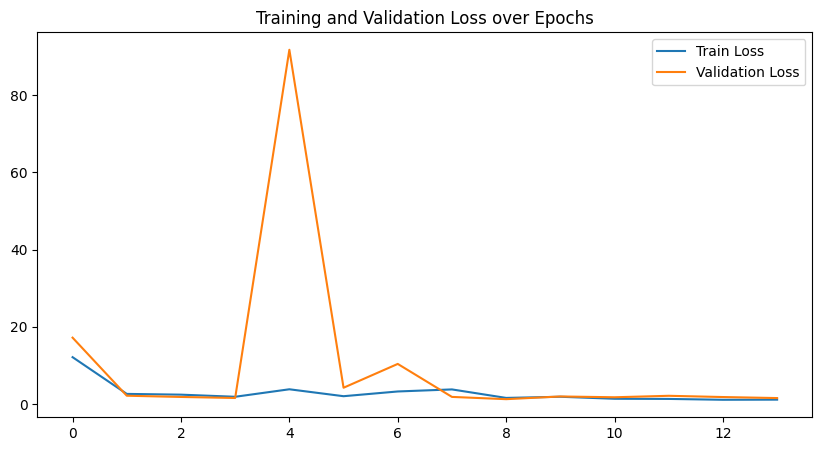

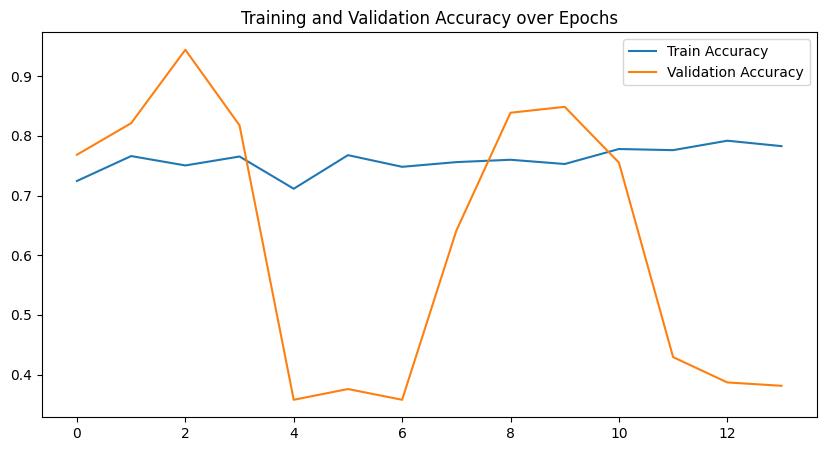

In [45]:
epochs = 20

# Early stopping callback to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    tf_dataset_train,
    validation_data=tf_dataset_val,
    epochs=epochs,
    callbacks=[early_stopping]
)

# Save the model
model.save('my_model.h5')

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()


In [46]:
test_loss, test_accuracy = model.evaluate(tf_dataset_test)

286/286 [==============================] - 56s 196ms/step - loss: 1.3394 - accuracy: 0.8023


### (iii) Report Precision, Recall, and F1 score for your model.

In [47]:
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

Test Loss: 1.3393630981445312
Test Accuracy: 0.8022994995117188


In [49]:
def evaluate_model(model, dataset, show_output=True):
  y_true = []
  y_pred = []
  for images, labels in dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

  report = classification_report(y_true, y_pred)
  return report

train_report = evaluate_model(model, tf_dataset_train)
val_report = evaluate_model(model, tf_dataset_val)
test_report = evaluate_model(model, tf_dataset_test)

In [54]:
print("Test Metrics for CNN Model:")
print(test_report)

Test Metrics for CNN Model:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      7415
           1       0.85      0.81      0.83     10850

    accuracy                           0.80     18265
   macro avg       0.80      0.80      0.80     18265
weighted avg       0.81      0.80      0.80     18265



In [55]:
print("Train Metrics for CNN Model:")
print(train_report)

Train Metrics for CNN Model:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      7415
           1       0.85      0.81      0.83     10850

    accuracy                           0.80     18265
   macro avg       0.80      0.80      0.80     18265
weighted avg       0.81      0.80      0.80     18265



In [56]:
print("Validation Metrics for CNN Model:")
print(val_report)

Validation Metrics for CNN Model:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86      3890
           1       0.69      0.99      0.81      2167

    accuracy                           0.84      6057
   macro avg       0.84      0.87      0.84      6057
weighted avg       0.88      0.84      0.84      6057



### (d) Transfer Learning

#### (d) (i),(ii),(iii),(iv) and (v) :

In [157]:
def create_model(num_classes):
    base_model = EfficientNetB0(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    base_model.trainable = False  # Freeze the base model
    tf.random.set_seed(42)

    image_augmentation1 = tf.keras.Sequential([
    layers.RandomContrast(factor=0.001),
    layers.RandomRotation(factor=0.0001)
])

    model = Sequential([
        Resizing(224, 224),
        image_augmentation1,
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(1024, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Number of classes in dataset
num_classes = 2

modellt = create_model(num_classes)

# Compile the model
modellt.compile(optimizer=Adam(learning_rate=0.0001),
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])


In [158]:
epochs = 20

# Train the model
history2 = modellt.fit(
    tf_dataset_train,
    epochs=epochs,
    validation_data=tf_dataset_val
)


Epoch 1/20
286/286 [==============================] - 94s 300ms/step - loss: 0.7229 - accuracy: 0.5572 - val_loss: 0.7106 - val_accuracy: 0.3578
Epoch 2/20
286/286 [==============================] - 84s 294ms/step - loss: 0.7095 - accuracy: 0.5650 - val_loss: 0.6939 - val_accuracy: 0.5214
Epoch 3/20
286/286 [==============================] - 84s 292ms/step - loss: 0.6979 - accuracy: 0.5753 - val_loss: 0.7204 - val_accuracy: 0.3318
Epoch 4/20
286/286 [==============================] - 83s 290ms/step - loss: 0.6888 - accuracy: 0.5892 - val_loss: 0.7066 - val_accuracy: 0.4052
Epoch 5/20
286/286 [==============================] - 84s 292ms/step - loss: 0.6874 - accuracy: 0.5878 - val_loss: 0.7042 - val_accuracy: 0.4314
Epoch 6/20
286/286 [==============================] - 84s 292ms/step - loss: 0.6768 - accuracy: 0.5948 - val_loss: 0.6832 - val_accuracy: 0.6312
Epoch 7/20
286/286 [==============================] - 84s 293ms/step - loss: 0.6758 - accuracy: 0.5953 - val_loss: 0.6938 - val_ac

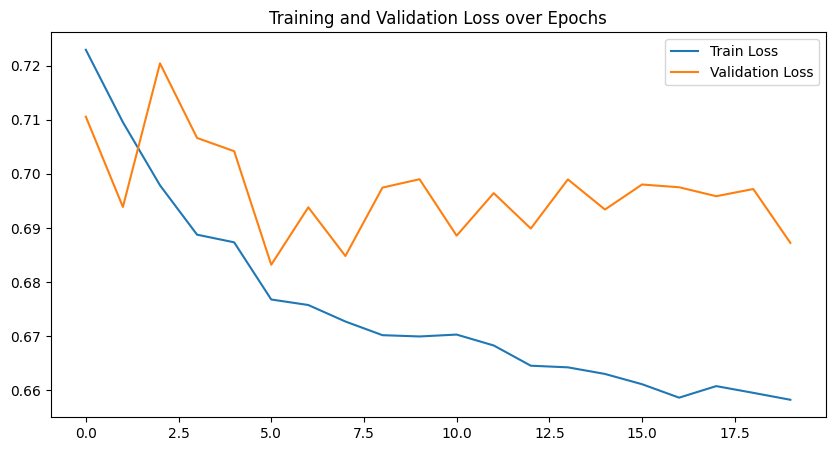

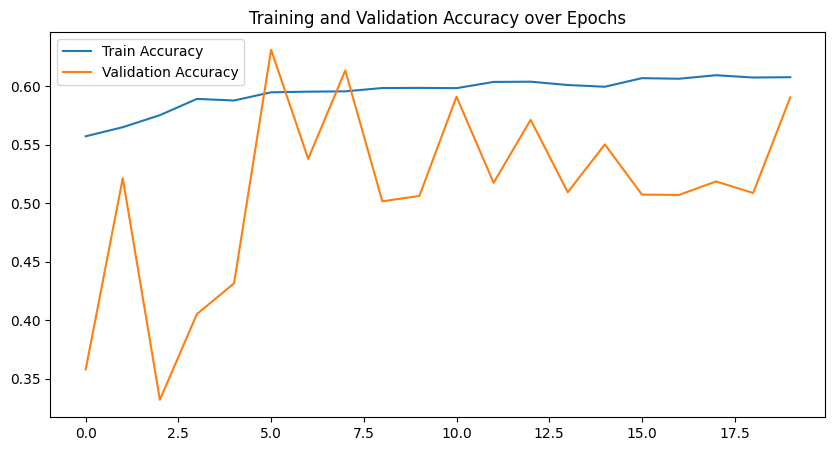

In [161]:
# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

# Plotting the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()


In [163]:
from sklearn.metrics import classification_report

def evaluate_model(model, dataset, show_output=True):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))

    report = classification_report(y_true, y_pred)
    return report

# Assuming you have tf_datasets for train, validation, and test sets
train_report1 = evaluate_model(modellt, tf_dataset_train)
val_report1 = evaluate_model(modellt, tf_dataset_val)
test_report1 = evaluate_model(modellt, tf_dataset_test)

In [164]:
print("Test Metrics for EfficientNetB0 Model:")
print(test_report1)

Test Metrics for EfficientNetB0 Model:
              precision    recall  f1-score   support

           0       0.52      0.63      0.57      7415
           1       0.71      0.61      0.65     10850

    accuracy                           0.62     18265
   macro avg       0.61      0.62      0.61     18265
weighted avg       0.63      0.62      0.62     18265



In [165]:
print("Train Metrics for EfficientNetB0 Model:")
print(train_report1)

Train Metrics for EfficientNetB0 Model:
              precision    recall  f1-score   support

           0       0.52      0.63      0.57      7415
           1       0.71      0.61      0.65     10850

    accuracy                           0.62     18265
   macro avg       0.61      0.62      0.61     18265
weighted avg       0.63      0.62      0.62     18265



In [166]:
print("Validation Metrics for EfficientNetB0 Model:")
print(val_report1)

Validation Metrics for EfficientNetB0 Model:
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      3890
           1       0.40      0.30      0.34      2167

    accuracy                           0.59      6057
   macro avg       0.53      0.53      0.52      6057
weighted avg       0.57      0.59      0.57      6057



In [167]:
test_lossEN, test_accuracyEN = modellt.evaluate(tf_dataset_test)

286/286 [==============================] - 62s 216ms/step - loss: 0.6608 - accuracy: 0.6160


In [168]:
print('Test Loss for EfficientNetB0:', test_lossEN)
print('Test Accuracy for EfficientNetB0:', test_accuracyEN)

Test Loss for EfficientNetB0: 0.6607851386070251
Test Accuracy for EfficientNetB0: 0.6160416007041931


### ResNet50 Model

In [175]:
def create_resnet50_model(num_classes):
    base_model = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    base_model.trainable = False  # Freeze the base model
    tf.random.set_seed(42)

    # Data augmentation layer
    data_augmentation = Sequential([
        preprocessing.RandomContrast(factor=0.001),
        preprocessing.RandomRotation(factor=0.0001)
    ])

    model = Sequential([
        Resizing(224, 224),
        data_augmentation,
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(1024, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model


num_classes_resnet50 = 2

resnet50_model = create_resnet50_model(num_classes_resnet50)

# Compile the ResNet50 model
resnet50_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss=SparseCategoricalCrossentropy(),
                       metrics=['accuracy'])


In [177]:
epochs = 20

from tensorflow.keras.callbacks import ModelCheckpoint

# Define a model checkpoint callback to save the best ResNet50 model
model_checkpoint_resnet50 = ModelCheckpoint('best_resnet50_model.h5', save_best_only=True)

# Early stopping callback to prevent overfitting
early_stopping_resnet50 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the ResNet50 model
history_resnet50 = resnet50_model.fit(
    tf_dataset_train,
    epochs=epochs,
    validation_data=tf_dataset_val,
    callbacks=[early_stopping_resnet50, model_checkpoint_resnet50]
)


Epoch 1/20
286/286 [==============================] - 92s 321ms/step - loss: 0.2814 - accuracy: 0.8711 - val_loss: 0.8388 - val_accuracy: 0.6748
Epoch 2/20
286/286 [==============================] - 91s 317ms/step - loss: 0.2570 - accuracy: 0.8840 - val_loss: 1.2256 - val_accuracy: 0.6487
Epoch 3/20
286/286 [==============================] - 92s 319ms/step - loss: 0.2421 - accuracy: 0.8961 - val_loss: 1.3280 - val_accuracy: 0.6439
Epoch 4/20
286/286 [==============================] - 91s 317ms/step - loss: 0.2307 - accuracy: 0.9004 - val_loss: 1.3149 - val_accuracy: 0.6515
Epoch 5/20
286/286 [==============================] - 92s 320ms/step - loss: 0.2213 - accuracy: 0.9034 - val_loss: 1.3305 - val_accuracy: 0.6478
Epoch 6/20
286/286 [==============================] - 91s 316ms/step - loss: 0.2131 - accuracy: 0.9083 - val_loss: 1.3488 - val_accuracy: 0.6602
Epoch 7/20
286/286 [==============================] - 91s 316ms/step - loss: 0.2028 - accuracy: 0.9154 - val_loss: 1.3717 - val_ac

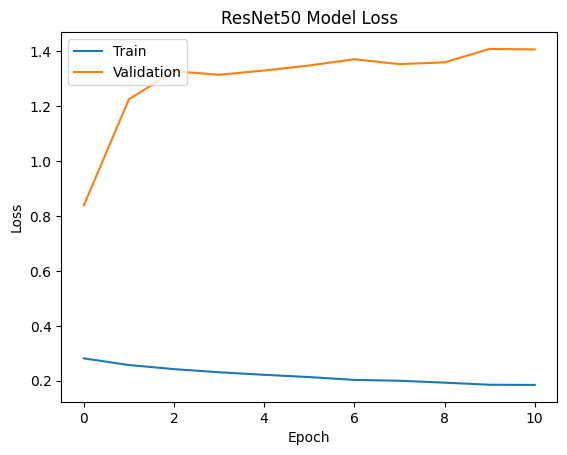

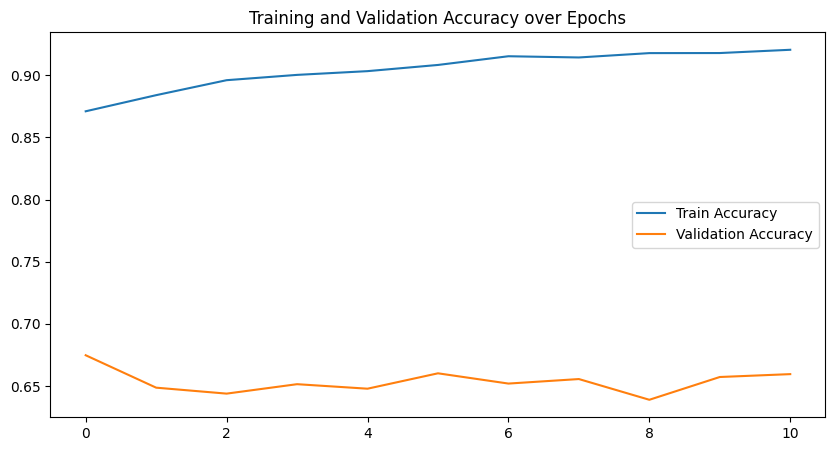

In [178]:
# Plotting training and validation loss for ResNet50
plt.plot(history_resnet50.history['loss'])
plt.plot(history_resnet50.history['val_loss'])
plt.title('ResNet50 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('resnet50_loss_plot.png')


# Plotting the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_resnet50.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet50.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [181]:
# Load the best ResNet50 model
best_resnet50_model = tf.keras.models.load_model('best_resnet50_model.h5')

# Evaluate the best ResNet50 model on test data
test_loss_resnet50, test_accuracy_resnet50 = best_resnet50_model.evaluate(tf_dataset_test)
print(f"ResNet50 Test Loss: {test_loss_resnet50}, Test Accuracy: {test_accuracy_resnet50}")

286/286 [==============================] - 69s 235ms/step - loss: 0.3116 - accuracy: 0.8750
ResNet50 Test Loss: 0.3116271197795868, Test Accuracy: 0.8749520778656006


In [182]:
train_report2 = evaluate_model(best_resnet50_model, tf_dataset_train)
val_report2 = evaluate_model(best_resnet50_model, tf_dataset_val)
test_report2 = evaluate_model(best_resnet50_model, tf_dataset_test)

In [186]:
print("Test Metrics for ResNet50 Model:")
print(test_report2)

Test Metrics for ResNet50 Model:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      7415
           1       0.95      0.83      0.89     10850

    accuracy                           0.87     18265
   macro avg       0.87      0.89      0.87     18265
weighted avg       0.89      0.87      0.88     18265



In [187]:
print("Train Metrics for ResNet50 Model:")
print(train_report2)

Train Metrics for ResNet50 Model:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      7415
           1       0.95      0.83      0.89     10850

    accuracy                           0.87     18265
   macro avg       0.87      0.89      0.87     18265
weighted avg       0.89      0.87      0.88     18265



In [188]:
print("Validation Metrics for ResNet50 Model:")
print(val_report2)

Validation Metrics for ResNet50 Model:
              precision    recall  f1-score   support

           0       0.98      0.50      0.66      3890
           1       0.52      0.98      0.68      2167

    accuracy                           0.67      6057
   macro avg       0.75      0.74      0.67      6057
weighted avg       0.82      0.67      0.67      6057



### VGG16 Model

In [189]:
def create_vgg16_model(num_classes):
    base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    base_model.trainable = False  # Freeze the base model
    tf.random.set_seed(42)

    # Data augmentation layer
    data_augmentation = Sequential([
        preprocessing.RandomContrast(factor=0.001),
        preprocessing.RandomRotation(factor=0.0001)
    ])

    model = Sequential([
        Resizing(224, 224),
        data_augmentation,
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(1024, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Number of classes in your dataset
num_classes_vgg16 = 2

vgg16_model = create_vgg16_model(num_classes_vgg16)

# Compile the VGG16 model
vgg16_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss=SparseCategoricalCrossentropy(),
                     metrics=['accuracy'])


58889256/58889256 [==============================] - 0s 0us/step


In [190]:
# Define a model checkpoint callback to save the best ResNet50 model
model_checkpoint_vgg16 = ModelCheckpoint('best_vgg16_model.h5', save_best_only=True)

# Early stopping callback to prevent overfitting
early_stopping_vgg16 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


epochs = 20

# Train the VGG16 model
history_vgg16 = vgg16_model.fit(
    tf_dataset_train,
    epochs=epochs,
    validation_data=tf_dataset_val,
    callbacks=[early_stopping_vgg16, model_checkpoint_vgg16]
)

Epoch 1/20
286/286 [==============================] - 101s 338ms/step - loss: 0.2577 - accuracy: 0.8950 - val_loss: 0.6472 - val_accuracy: 0.6611
Epoch 2/20


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


286/286 [==============================] - 95s 329ms/step - loss: 0.1656 - accuracy: 0.9351 - val_loss: 0.7690 - val_accuracy: 0.7299
Epoch 3/20
286/286 [==============================] - 95s 330ms/step - loss: 0.1370 - accuracy: 0.9470 - val_loss: 0.8407 - val_accuracy: 0.7451
Epoch 4/20
286/286 [==============================] - 95s 330ms/step - loss: 0.1210 - accuracy: 0.9537 - val_loss: 0.8732 - val_accuracy: 0.7453
Epoch 5/20
286/286 [==============================] - 95s 330ms/step - loss: 0.1074 - accuracy: 0.9586 - val_loss: 0.8951 - val_accuracy: 0.7499
Epoch 6/20
286/286 [==============================] - 94s 327ms/step - loss: 0.0977 - accuracy: 0.9620 - val_loss: 0.9392 - val_accuracy: 0.7515
Epoch 7/20
286/286 [==============================] - 94s 327ms/step - loss: 0.0886 - accuracy: 0.9668 - val_loss: 0.9664 - val_accuracy: 0.7595
Epoch 8/20
286/286 [==============================] - 94s 326ms/step - loss: 0.0829 - accuracy: 0.9684 - val_loss: 0.9606 - val_accuracy: 0.7

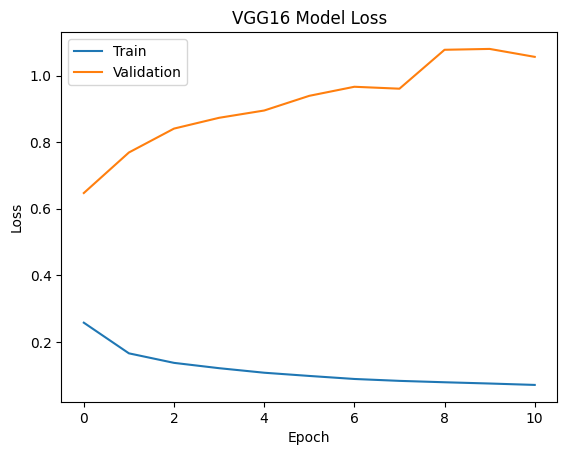

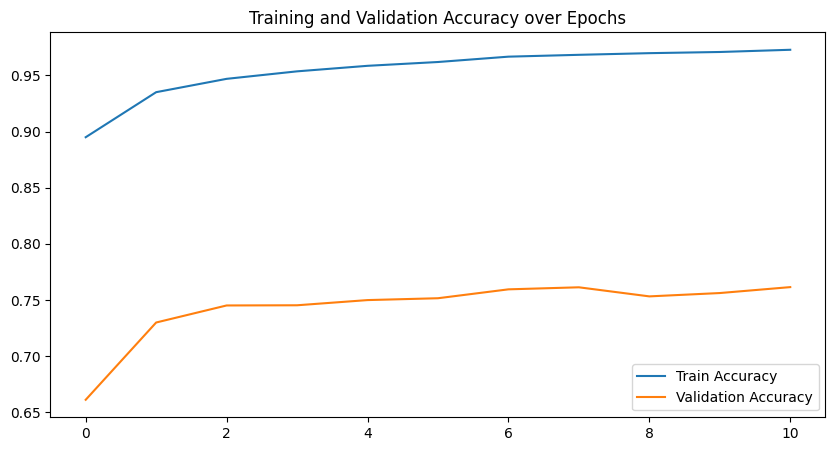

In [191]:
# Plotting training and validation loss for VGG16
plt.plot(history_vgg16.history['loss'])
plt.plot(history_vgg16.history['val_loss'])
plt.title('VGG16 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('vgg16_loss_plot.png')

# Plotting the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [193]:
# Load the best VGG16 model
best_vgg16_model = tf.keras.models.load_model('best_vgg16_model.h5')

# Evaluate the best VGG16 model on test data
test_loss_vgg16, test_accuracy_vgg16 = best_vgg16_model.evaluate(tf_dataset_test)
print(f"VGG16 Test Loss: {test_loss_vgg16}, Test Accuracy: {test_accuracy_vgg16}")

286/286 [==============================] - 71s 245ms/step - loss: 0.3155 - accuracy: 0.8875
VGG16 Test Loss: 0.3155497908592224, Test Accuracy: 0.8874897360801697


In [194]:
train_report3 = evaluate_model(best_vgg16_model, tf_dataset_train)
val_report3 = evaluate_model(best_vgg16_model, tf_dataset_val)
test_report3 = evaluate_model(best_vgg16_model, tf_dataset_test)

In [195]:
print("Test Metrics for VGG16 Model:")
print(test_report3)

Test Metrics for VGG16 Model:
              precision    recall  f1-score   support

           0       0.95      0.76      0.85      7415
           1       0.86      0.97      0.91     10850

    accuracy                           0.89     18265
   macro avg       0.90      0.87      0.88     18265
weighted avg       0.89      0.89      0.88     18265



In [196]:
print("Train Metrics for VGG16 Model:")
print(train_report3)

Train Metrics for VGG16 Model:
              precision    recall  f1-score   support

           0       0.95      0.76      0.85      7415
           1       0.86      0.97      0.91     10850

    accuracy                           0.89     18265
   macro avg       0.90      0.87      0.88     18265
weighted avg       0.89      0.89      0.88     18265



In [198]:
print("Validation Metrics for VGG16 Model:")
print(val_report3)

Validation Metrics for VGG16 Model:
              precision    recall  f1-score   support

           0       0.99      0.48      0.64      3890
           1       0.51      0.99      0.68      2167

    accuracy                           0.66      6057
   macro avg       0.75      0.73      0.66      6057
weighted avg       0.82      0.66      0.66      6057



### (d) (vi): Comparison:

- **EfficientNetB0 vs. CNN + MLP**: The CNN + MLP model outperforms the EfficientNetB0 model across all metrics, indicating that the EfficientNetB0 model may not be well-tuned or well-suited for this particular task as compared to the CNN + MLP model.

<br>

- **ResNet50 vs. CNN + MLP**: The ResNet50 model shows significant improvement over the CNN + MLP model, especially in terms of recall for class 0 and precision for class 1. It also has a higher overall accuracy and F1-scores, indicating that this transfer learning model has learned more generalized features that perform better on the test set.

<br>

- **VGG16 vs. CNN + MLP**: VGG16 shows the best performance among all models, with the highest overall accuracy and F1-scores. This suggests that the features extracted by VGG16 are very effective for this classification task, and the model is quite balanced in terms of precision and recall for both classes.

<br>

In summary, the **VGG16 and ResNet50** transfer learning models have **outperformed** the **CNN + MLP model**, indicating that the pre-trained networks have learned robust features that generalize well to the test data. The EfficientNetB0 model, however, did not perform as well, which could be due to various factors such as model complexity, overfitting, or a need for further fine-tuning. Transfer learning models typically benefit from large datasets and pre-trained weights that have been trained on a wide variety of features, which can explain their superior performance in many tasks compared to models trained from scratch like the CNN + MLP model.